# Regression with an Insurance Dataset
*Playground Series - Season 4, Episode 12*

## 1. Adatbetöltés

In [1]:
import pandas as pd

pd.set_option("display.float_format", "{:,.4f}".format)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.shape, test.shape)
train.info()
train.describe()


(1200000, 21) (800000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  str    
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  str    
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  str    
 7   Occupation            841925 non-null   str    
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  str    
 10  Policy Type           1200000 non-null  str    
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,"1,200,000.0000","1,181,295.0000","1,155,051.0000","1,090,328.0000","1,125,924.0000","835,971.0000","1,199,994.0000","1,062,118.0000","1,199,999.0000","1,200,000.0000"
mean,"599,999.5000",41.1456,"32,745.2178",2.0099,25.6139,1.0027,9.5699,592.9244,5.0182,"1,102.5448"
std,"346,410.3059",13.5399,"32,179.5061",1.4173,12.2035,0.9828,5.7762,149.9819,2.5943,864.9989
min,0.0000,18.0000,1.0000,0.0000,2.0122,0.0000,0.0000,300.0000,1.0000,20.0000
25%,"299,999.7500",30.0000,"8,001.0000",1.0000,15.9190,0.0000,5.0000,468.0000,3.0000,514.0000
50%,"599,999.5000",41.0000,"23,911.0000",2.0000,24.5786,1.0000,10.0000,595.0000,5.0000,872.0000
75%,"899,999.2500",53.0000,"44,634.0000",3.0000,34.5272,2.0000,15.0000,721.0000,7.0000,"1,509.0000"
max,"1,199,999.0000",64.0000,"149,997.0000",4.0000,58.9759,9.0000,19.0000,849.0000,9.0000,"4,999.0000"


## 2. Célváltozó eloszlás

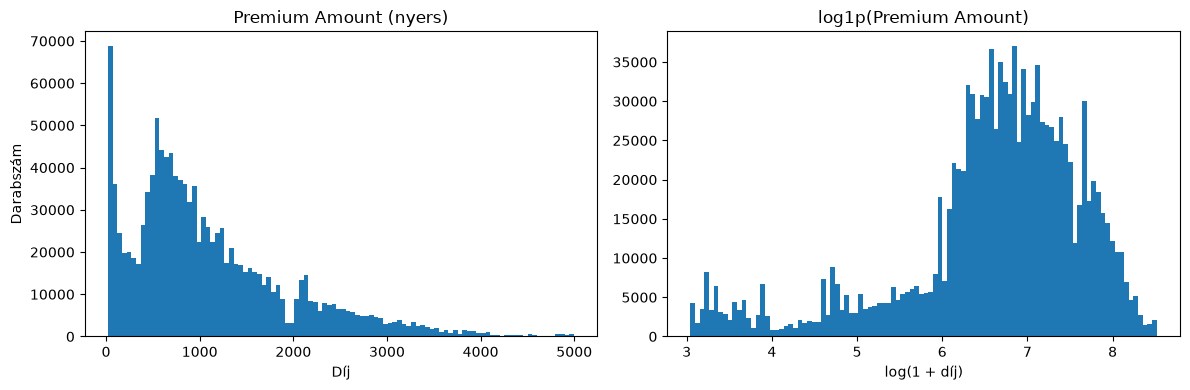

In [2]:
import numpy as np
import matplotlib.pyplot as plt

target = train["Premium Amount"]

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(target, bins=100)
axes[0].set_title("Premium Amount (nyers)")
axes[0].set_xlabel("Díj")
axes[0].set_ylabel("Darabszám")

axes[1].hist(np.log1p(target), bins=100)
axes[1].set_title("log1p(Premium Amount)")
axes[1].set_xlabel("log(1 + díj)")

plt.tight_layout()
plt.show()

## 3. Hiányzó értékek

In [3]:
missing = (
    train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing[missing > 0].round(2)

Previous Claims        30.3400
Occupation             29.8400
Credit Score           11.4900
Number of Dependents    9.1400
Customer Feedback       6.4900
Health Score            6.1700
Annual Income           3.7500
Age                     1.5600
Marital Status          1.5400
Vehicle Age             0.0000
Insurance Duration      0.0000
dtype: float64

## 4. Kategorikus változók eloszlása

In [4]:
cat_cols = train.select_dtypes(include=["object", "string"]).columns
print(list(cat_cols))

for col in cat_cols:
    if col == "Policy Start Date":
        continue
    print(f"\n=== {col} ({train[col].nunique()} különboző érték) ===")
    print(train[col].value_counts(normalize=True, dropna=False).mul(100).round(2))

['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']

=== Gender (2 különboző érték) ===
Gender
Male     50.2100
Female   49.7900
Name: proportion, dtype: float64

=== Marital Status (3 különboző érték) ===
Marital Status
Single     32.9500
Married    32.8600
Divorced   32.6500
NaN         1.5400
Name: proportion, dtype: float64

=== Education Level (4 különboző érték) ===
Education Level
Master's      25.3200
PhD           25.2900
Bachelor's    25.2700
High School   24.1200
Name: proportion, dtype: float64

=== Occupation (3 különboző érték) ===
Occupation
NaN             29.8400
Employed        23.5600
Self-Employed   23.5500
Unemployed      23.0400
Name: proportion, dtype: float64

=== Location (3 különboző érték) ===
Location
Suburban   33.4600
Rural      33.4100
Urban      33.1300
Name: proportion, dtype: float64

=== Policy Type (3 különboző érték

## 5. Összefüggések a célváltozóval

### 5.1 Kategóriák és az átlagos díj

In [5]:
train["log_premium"] = np.log1p(train["Premium Amount"])

for col in cat_cols:
    if col == "Policy Start Date":
        continue
    means = train.groupby(col, dropna=False)["log_premium"].mean().round(3)
    print(f"\n=== {col} ===")
    print(means)


=== Gender ===
Gender
Female   6.5950
Male     6.5930
Name: log_premium, dtype: float64

=== Marital Status ===
Marital Status
Divorced   6.5900
Married    6.5920
Single     6.5940
NaN        6.7230
Name: log_premium, dtype: float64

=== Education Level ===
Education Level
Bachelor's    6.5940
High School   6.5950
Master's      6.5920
PhD           6.5940
Name: log_premium, dtype: float64

=== Occupation ===
Occupation
Employed        6.6030
Self-Employed   6.5950
Unemployed      6.5960
NaN             6.5840
Name: log_premium, dtype: float64

=== Location ===
Location
Rural      6.5920
Suburban   6.5930
Urban      6.5960
Name: log_premium, dtype: float64

=== Policy Type ===
Policy Type
Basic           6.5950
Comprehensive   6.5940
Premium         6.5930
Name: log_premium, dtype: float64

=== Customer Feedback ===
Customer Feedback
Average   6.5840
Good      6.5870
Poor      6.5890
NaN       6.6970
Name: log_premium, dtype: float64

=== Smoking Status ===
Smoking Status
No    6.5930


### 5.2 Numerikus változók: korreláció

In [6]:
num_cols = train.select_dtypes(include="number").columns.drop(["id", "Premium Amount", "log_premium"])
train[num_cols].corrwith(train["log_premium"]).sort_values().round(3)

Annual Income          -0.0880
Credit Score           -0.0510
Age                    -0.0020
Number of Dependents   -0.0020
Vehicle Age             0.0000
Insurance Duration      0.0000
Health Score            0.0170
Previous Claims         0.0360
dtype: float64

### 5.3 A hiány mint információ

In [7]:
for col in ["Previous Claims", "Occupation", "Credit Score"]:
    means = train.groupby(train[col].isna())["log_premium"].mean().round(3)
    print(f"\n{col} hiányzik? -> \n{means}")


Previous Claims hiányzik? -> 
Previous Claims
False   6.6040
True    6.5700
Name: log_premium, dtype: float64

Occupation hiányzik? -> 
Occupation
False   6.5980
True    6.5840
Name: log_premium, dtype: float64

Credit Score hiányzik? -> 
Credit Score
False   6.5990
True    6.5540
Name: log_premium, dtype: float64


## 6. Nemlineáris összefüggések

### 6.1 Previous Claims

In [8]:
print(train.groupby("Previous Claims", dropna=False)["log_premium"].agg(["mean", "count"]))


                  mean   count
Previous Claims               
0.0000          6.5736  305433
1.0000          6.5846  300811
2.0000          6.6592  167661
3.0000          6.6911   49011
4.0000          6.7343   10668
5.0000          6.7274    2018
6.0000          6.8094     302
7.0000          7.0240      58
8.0000          6.7783       8
9.0000          7.3871       1
NaN             6.5703  364029


A hiányzó kárszámú csoport átlaga nagyjából megegyezik a 0 kárszámú csoportjáéval (6.5703 / 6.5736) --> A hiáynzó érték 0 kárszámot implikál?

### 6.2 Éves jövedelem decilisenként

In [9]:

income_bins = pd.qcut(train["Annual Income"], q=10)
print(train.groupby(income_bins, observed=True)['log_premium'].mean())

Annual Income
(0.999, 2627.0]       6.5905
(2627.0, 5905.0]      6.6857
(5905.0, 11119.0]     6.6798
(11119.0, 17019.0]    6.6851
(17019.0, 23911.0]    6.6945
(23911.0, 29585.0]    6.7175
(29585.0, 39644.0]    6.6948
(39644.0, 51810.0]    6.6025
(51810.0, 81075.0]    6.3522
(81075.0, 149997.0]   6.3944
Name: log_premium, dtype: float64


## 7. A kötvény kezdő dátuma
*+Dátum oszlop str -> date*

In [10]:
train["Policy Start Date"] = pd.to_datetime(train["Policy Start Date"])
print(train["Policy Start Date"].min(), train["Policy Start Date"].max())

by_yr = train.groupby(train["Policy Start Date"].dt.year)["log_premium"].agg(["mean", "count"])
print(by_yr)
# train["Policy Start Date"].dt.time.nunique()

2019-08-17 15:21:39.080371 2024-08-15 15:21:39.287115
                    mean   count
Policy Start Date               
2019              6.6628   84289
2020              6.5922  242087
2021              6.5869  244918
2022              6.5878  245671
2023              6.5842  239067
2024              6.5948  143968


Adat: 2019 - 2024 (a kezdő és vég év csak részleges év -> kisebb a db számuk)

## 8. Összefoglalás

- A célváltozó jobbra ferde, ezért log-skálán kell modellezni. (amugy is a contest RMSLE metrikájú). A nagyon alacsony díjú csoport okozza majd a legtöbb hibát.
- Az adat szintetikus és nagyon zajos. A kategóriák szinte tökéletesen egyenletesen oszlanak el, és egyenként alig hatnak a díjra.
- A hiányzó értékek információt hordoznak (Marital Status, Customer Feedback, Credit Score), ezért nem kell őket kitölteni még.
- A legerősebb jel az éves jövedelem. Nemlineáris, lépcsőzetes összefüggéssel. Ezt a korreláció alulbecsüli.
- A "Previous Claims" monoton növekvő összefüggést mutat, és a hiánya a 0 kárszámhoz hasonlít.
- A kötvény kezdő dátumából új feature-öket lehet kinyerni.